In [87]:
import pandas as pd
import numpy as np
import re

#SQL injection strings - https://huggingface.co/datasets/firdhokk/autotrain-data-sql-injection
df = pd.read_csv('SQL_I.csv')
df = df.rename(columns={'Data': 'text'})
def iter_passwords(path):
    with open(path, 'r', encoding='latin-1') as f:
        for line in f:
            yield line.rstrip('\n')

print(df.head())

            text  Label
0       'sqlvuln      1
1      '+sqlvuln      1
2       sqlvuln;      1
3   ( sqlvuln )       1
4  a' or 1 = 1--      1


In [88]:
def clean_text(s):
  s = s.lower().strip()
  s = re.sub(r"\s+", " ", s)
  return s

df["text"] = df["text"].astype(str).map(clean_text)
print(df.head())
print(df['Label'].value_counts())

            text  Label
0       'sqlvuln      1
1      '+sqlvuln      1
2       sqlvuln;      1
3    ( sqlvuln )      1
4  a' or 1 = 1--      1
Label
1    22953
0    16040
Name: count, dtype: int64


In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix, precision_score
import pickle

X = df['text'].values
y = df['Label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

filename = 'trained_model.pkl'
if(input("model trained?") == 'y'):
    # Load the model
    with open(filename, 'rb') as file:
      pipe = pickle.load(file)
else:
  tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,6), max_features=30000)
  clf = LogisticRegression(max_iter=1000, class_weight="balanced")
  pipe = Pipeline([("tfidf", tfidf), ("clf", clf)])
  pipe.fit(X_train, y_train)

  with open(filename, 'wb') as file:
    pickle.dump(pipe, file)

y_proba = pipe.predict_proba(X_test)[:,1]
thres = 0.9
y_pred = y_proba >= thres
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1]))
#print("Cross Validation Score:", cross_val_score(pipe, X, y, cv=5, scoring='accuracy'))

model trained?y
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3208
           1       1.00      0.92      0.96      4591

    accuracy                           0.95      7799
   macro avg       0.95      0.96      0.95      7799
weighted avg       0.96      0.95      0.95      7799

ROC AUC: 0.9996610860672323


In [80]:
tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,6), max_features=30000)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_test = tfidf.fit_transform(X_test)
print(X_test)

KeyboardInterrupt: 

In [102]:
print(pipe.predict_proba(np.array(["' or 1=1"])))

[[0.00166469 0.99833531]]


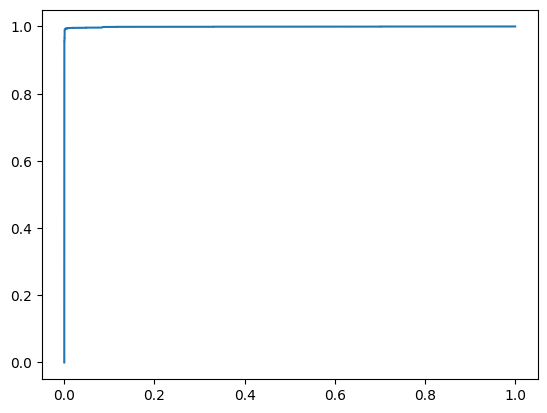

In [42]:
import matplotlib.pyplot as plt

probas = pipe.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, probas)

plt.plot(fpr, tpr)
plt.show()